# NSL-KDD Intrusion Detection

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, pairwise_distances_argmin
from sklearn.metrics import pairwise_distances_argmin_min

from imblearn.over_sampling import BorderlineSMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import shap
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [ ]:
train = pd.read_csv("kdd_train.csv", header=None)
test = pd.read_csv("kdd_test.csv", header=None)

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label"
]

train.columns = columns
test.columns = columns

train = train.iloc[1:].copy()
test = test.iloc[1:].copy()

## 2. Label Mapping & Filtering

In [ ]:
common_labels = set(train['label']) & set(test['label'])
train = train[train['label'].isin(common_labels)]
test = test[test['label'].isin(common_labels)]

def map_attack(label):
    if label == 'normal':
        return 'normal'
    elif label in ['back','land','neptune','pod','smurf','teardrop',
                   'apache2','udpstorm','processtable','worm']:
        return 'dos'
    elif label in ['ipsweep','nmap','portsweep','satan','mscan','saint']:
        return 'probe'
    elif label in ['ftp_write','guess_passwd','imap','multihop','phf','spy',
                   'warezclient','warezmaster','sendmail','named',
                   'snmpgetattack','snmpguess','xlock','xsnoop','httptunnel']:
        return 'r2l'
    elif label in ['buffer_overflow','loadmodule','perl','rootkit',
                   'ps','sqlattack','xterm']:
        return 'u2r'
    else:
        return 'unknown'

train['label'] = train['label'].apply(map_attack)
test['label'] = test['label'].apply(map_attack)

X_train = train.drop(columns=["label"])
y_train = train["label"]
X_test = test.drop(columns=["label"])
y_test = test["label"]

print("Train distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Train distribution: Counter({'normal': 67343, 'dos': 45927, 'probe': 11656, 'r2l': 993, 'u2r': 52})
Test distribution: Counter({'normal': 11245, 'dos': 7562, 'probe': 1754, 'r2l': 811, 'u2r': 26})


## 3. Preprocessing
### FIX: LabelEncoder disimpan per kolom dalam dict agar tidak tertimpa

In [ ]:
categorical_cols = ["protocol_type", "service", "flag"]

# FIX: simpan setiap encoder dalam dict, bukan variabel tunggal yang ditimpa
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    # Handle unseen categories di test set
    X_test[col] = X_test[col].apply(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le  # simpan encoder per kolom

print("Categorical encoding done. Encoders saved:", list(label_encoders.keys()))

Categorical encoding done. Encoders saved: ['protocol_type', 'service', 'flag']


## 4. Target Label Encoder & Scaling (Full Features)

In [ ]:
# Label encoder untuk target - fit hanya dari y_train
label_encoder = LabelEncoder()
label_encoder.fit(y_train)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Scaling - fit hanya dari X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Classes:", label_encoder.classes_)
print("X_train_scaled shape:", X_train_scaled.shape)

Classes: ['dos' 'normal' 'probe' 'r2l' 'u2r']
X_train_scaled shape: (125971, 41)


## 5. Baseline: XGBoost tanpa Sampling (Unbalanced)

In [ ]:
print("Training baseline XGBoost (unbalanced)...")

model_xgb_unbalanced = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
model_xgb_unbalanced.fit(X_train_scaled, y_train_encoded)
y_pred_unbalanced = model_xgb_unbalanced.predict(X_test_scaled)

print("\n=== Baseline (Unbalanced) ===")
print(classification_report(y_test_encoded, y_pred_unbalanced,
                             target_names=label_encoder.classes_))

Training baseline XGBoost (unbalanced)...

=== Baseline (Unbalanced) ===
              precision    recall  f1-score   support

         dos       1.00      1.00      1.00      7562
      normal       0.94      0.99      0.97     11245
       probe       0.96      1.00      0.98      1754
         r2l       0.99      0.20      0.33       811
         u2r       1.00      0.50      0.67        26

    accuracy                           0.96     21398
   macro avg       0.98      0.74      0.79     21398
weighted avg       0.97      0.96      0.95     21398



## 6. Hybrid Sampling: KMeans Undersampling + BorderlineSMOTE

In [ ]:
def kmeans_undersample(X, y, sampling_strategy, random_state=42):
    """
    KMeans Undersampling:
    - Cluster setiap kelas mayoritas menjadi k cluster
    - Pilih 1 sampel ASLI terdekat dengan centroid tiap cluster
    - Berbeda dengan ClusterCentroids yang membuat titik sintetis
    """
    X_result, y_result = [], []
    unique_classes = np.unique(y)

    for cls in unique_classes:
        mask = (y == cls) if not hasattr(y, 'values') else (y.values == cls)
        X_cls = X[mask]
        target_n = sampling_strategy.get(cls, len(X_cls))

        if len(X_cls) <= target_n:
            # Kelas minoritas atau sudah <= target: ambil semua
            X_result.append(X_cls)
            y_result.extend([cls] * len(X_cls))
        else:
            # Kelas mayoritas: cluster lalu pilih sampel asli terdekat centroid
            print(f"  KMeans clustering class '{cls}': {len(X_cls)} -> {target_n} samples")
            km = KMeans(n_clusters=target_n, random_state=random_state,
                        n_init=10, max_iter=300)
            km.fit(X_cls)

            # Pilih index sampel asli yang paling dekat dengan setiap centroid
            closest_idx = pairwise_distances_argmin(km.cluster_centers_, X_cls)
            # Pastikan tidak ada duplikat (jika 2 centroid dekat ke sampel yang sama)
            closest_idx = np.unique(closest_idx)

            # Jika unique idx kurang dari target karena duplikat,
            # tambahkan sampel acak dari sisa
            if len(closest_idx) < target_n:
                remaining = np.setdiff1d(np.arange(len(X_cls)), closest_idx)
                rng = np.random.RandomState(random_state)
                extra = rng.choice(remaining,
                                   size=target_n - len(closest_idx),
                                   replace=False)
                closest_idx = np.concatenate([closest_idx, extra])

            X_result.append(X_cls[closest_idx])
            y_result.extend([cls] * len(closest_idx))

    X_out = np.vstack(X_result)
    y_out = np.array(y_result)
    return X_out, y_out


# ---- Jalankan KMeans Undersampling ----
print("Step 1: KMeans Undersampling (Majority Classes)")
print("Menggunakan sampel ASLI terdekat centroid, bukan titik sintetis\n")

sampling_strategy_under = {
    'normal': 15000,
    'dos':    10000,
    'probe':  8000,
    # r2l & u2r tidak disebutkan -> otomatis diambil semua (minority)
}

X_under, y_under = kmeans_undersample(
    X_train_scaled, y_train,
    sampling_strategy=sampling_strategy_under,
    random_state=42
)

print("\nAfter KMeans Undersampling:", Counter(y_under))


# ---- Jalankan BorderlineSMOTE ----
print("\nStep 2: BorderlineSMOTE Oversampling (Minority Classes)")

smote = BorderlineSMOTE(
    kind='borderline-2',
    sampling_strategy={
        'r2l': 6000,
        'u2r': 5000,
    },
    k_neighbors=2,
    random_state=42
)

X_res, y_res = smote.fit_resample(X_under, y_under)
print("After BorderlineSMOTE:", Counter(y_res))


Step 1: KMeans Undersampling (Majority Classes)
Menggunakan sampel ASLI terdekat centroid, bukan titik sintetis

  KMeans clustering class 'dos': 45927 -> 10000 samples
  KMeans clustering class 'normal': 67343 -> 15000 samples
  KMeans clustering class 'probe': 11656 -> 8000 samples

After KMeans Undersampling: Counter({np.str_('normal'): 15000, np.str_('dos'): 10000, np.str_('probe'): 8000, np.str_('r2l'): 993, np.str_('u2r'): 52})

Step 2: BorderlineSMOTE Oversampling (Minority Classes)
After BorderlineSMOTE: Counter({np.str_('normal'): 15000, np.str_('dos'): 10000, np.str_('probe'): 8000, np.str_('r2l'): 6000, np.str_('u2r'): 5000})


## 7. XGBoost dengan Hybrid Sampling (Full 41 Features)

In [ ]:
y_res_encoded = label_encoder.transform(y_res)

model_xgb = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
model_xgb.fit(X_res, y_res_encoded)

y_pred_xgb = model_xgb.predict(X_test_scaled)

print("=== XGBoost + Hybrid Sampling (41 Features) ===")
print(classification_report(y_test_encoded, y_pred_xgb,
                             target_names=label_encoder.classes_))

=== XGBoost + Hybrid Sampling (41 Features) ===
              precision    recall  f1-score   support

         dos       1.00      1.00      1.00      7562
      normal       0.95      0.99      0.97     11245
       probe       0.96      1.00      0.98      1754
         r2l       0.99      0.30      0.46       811
         u2r       1.00      0.58      0.73        26

    accuracy                           0.97     21398
   macro avg       0.98      0.77      0.83     21398
weighted avg       0.97      0.97      0.96     21398



## 8. SHAP Analysis

Calculating SHAP values from TRAINING set (X_res)...
Note: SHAP dihitung dari training set agar tidak terjadi information leakage
SHAP values shape: (5000, 41, 5)
Generating SHAP summary plot...


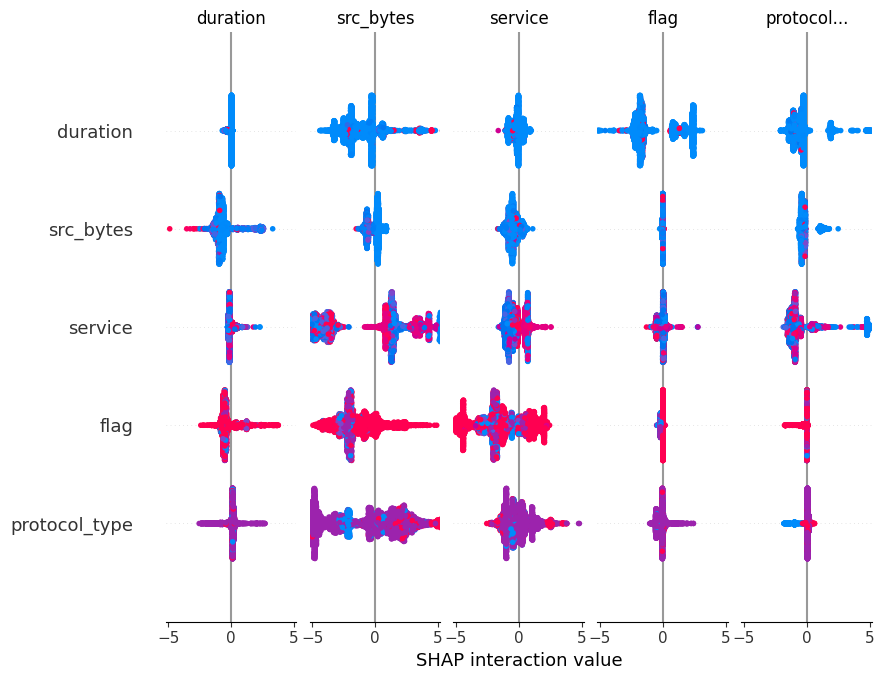

In [ ]:
import shap

print("Calculating SHAP values from TRAINING set (X_res)...")
print("Note: SHAP dihitung dari training set agar tidak terjadi information leakage")

explainer = shap.TreeExplainer(model_xgb)

# FIX: gunakan X_res (training set), BUKAN X_test_scaled
# Gunakan subsample agar lebih cepat jika data besar
shap_sample_size = min(5000, X_res.shape[0])
np.random.seed(42)
shap_indices = np.random.choice(X_res.shape[0], shap_sample_size, replace=False)
X_shap = X_res[shap_indices]

shap_values = explainer.shap_values(X_shap)

feature_names = X_train.columns.tolist()

print(f"SHAP values shape: {np.array(shap_values).shape}")
print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  class_names=label_encoder.classes_)

## 9. Feature Ranking dari SHAP

In [ ]:
shap_array = np.array(shap_values)

# Handle shape: bisa (n_classes, n_samples, n_features) atau (n_samples, n_features, n_classes)
if shap_array.ndim == 3:
    if shap_array.shape[0] == len(label_encoder.classes_):
        # Shape: (n_classes, n_samples, n_features) -> average over classes and samples
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 1))
    else:
        # Shape: (n_samples, n_features, n_classes) -> average over samples and classes
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))
else:
    mean_abs_shap = np.mean(np.abs(shap_array), axis=0)

feature_importance = dict(zip(feature_names, mean_abs_shap))
sorted_feature_importance = sorted(feature_importance.items(),
                                    key=lambda x: x[1], reverse=True)

print("\nTop 15 Features by Mean |SHAP| (from training set):")
for i, (feat, imp) in enumerate(sorted_feature_importance[:15], 1):
    print(f"{i:2d}. {feat}: {imp:.4f}")


Top 15 Features by Mean |SHAP| (from training set):
 1. src_bytes: 1.0911
 2. dst_bytes: 0.6849
 3. count: 0.6083
 4. service: 0.5145
 5. dst_host_same_src_port_rate: 0.5066
 6. dst_host_serror_rate: 0.4232
 7. dst_host_srv_count: 0.3732
 8. logged_in: 0.3163
 9. dst_host_diff_srv_rate: 0.2987
10. protocol_type: 0.2965
11. flag: 0.2441
12. dst_host_count: 0.2367
13. duration: 0.2266
14. dst_host_rerror_rate: 0.2253
15. dst_host_same_srv_rate: 0.2082


## 10. Retrain dengan Top N Features
### Pipeline konsisten: SHAP (dari train) → filter fitur → scale → KMeans Undersample → SMOTE → train

In [ ]:
results = {}
all_preds = {}

for top_n in [10, 20, 30]:
    print(f"\n{'='*55}")
    print(f" Processing Top {top_n} Features")
    print(f"{'='*55}")

    # 1. Pilih top N fitur dari SHAP (dihitung dari training set)
    top_features = [feat for feat, _ in sorted_feature_importance[:top_n]]
    print(f"  Features: {top_features}")

    # 2. Filter fitur dari data original (sebelum scaling)
    X_train_top = X_train[top_features]
    X_test_top  = X_test[top_features]

    # 3. Scaling — fit HANYA dari training set
    scaler_top = StandardScaler()
    X_train_top_scaled = scaler_top.fit_transform(X_train_top)
    X_test_top_scaled  = scaler_top.transform(X_test_top)

    # 4. KMeans Undersampling dari training set yang sudah difilter
    X_under_top, y_under_top = kmeans_undersample(
        X_train_top_scaled, y_train,
        sampling_strategy=sampling_strategy_under,
        random_state=42
    )
    print(f"  After KMeans Undersampling: {Counter(y_under_top)}")

    # 5. BorderlineSMOTE
    smote_top = BorderlineSMOTE(
        kind='borderline-2',
        sampling_strategy={'r2l': 6000, 'u2r': 5000},
        k_neighbors=2, random_state=42
    )
    X_res_top, y_res_top = smote_top.fit_resample(X_under_top, y_under_top)
    print(f"  After SMOTE: {Counter(y_res_top)}")

    # 6. Encode target
    y_res_top_encoded = label_encoder.transform(y_res_top)

    # 7. Train XGBoost
    model_top = XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42, n_jobs=-1
    )
    model_top.fit(X_res_top, y_res_top_encoded)

    # 8. Evaluasi di test set
    y_pred_top = model_top.predict(X_test_top_scaled)
    all_preds[top_n] = {
        'y_pred': y_pred_top,
        'model': model_top,
        'X_test_scaled': X_test_top_scaled,
        'X_res': X_res_top,
        'y_res_encoded': y_res_top_encoded,
        'top_features': top_features,
        'scaler': scaler_top,
    }

    report = classification_report(
        y_test_encoded, y_pred_top,
        target_names=label_encoder.classes_, output_dict=True
    )
    results[f'top_{top_n}'] = report

    print(f"\n  Classification Report (Top {top_n} Features):")
    print(classification_report(y_test_encoded, y_pred_top,
                                 target_names=label_encoder.classes_))



 Processing Top 10 Features
  Features: ['src_bytes', 'dst_bytes', 'count', 'service', 'dst_host_same_src_port_rate', 'dst_host_serror_rate', 'dst_host_srv_count', 'logged_in', 'dst_host_diff_srv_rate', 'protocol_type']
  KMeans clustering class 'dos': 45927 -> 10000 samples
  KMeans clustering class 'normal': 67343 -> 15000 samples
  KMeans clustering class 'probe': 11656 -> 8000 samples
  After KMeans Undersampling: Counter({np.str_('normal'): 15000, np.str_('dos'): 10000, np.str_('probe'): 8000, np.str_('r2l'): 993, np.str_('u2r'): 52})
  After SMOTE: Counter({np.str_('normal'): 15000, np.str_('dos'): 10000, np.str_('probe'): 8000, np.str_('r2l'): 6000, np.str_('u2r'): 5000})

  Classification Report (Top 10 Features):
              precision    recall  f1-score   support

         dos       1.00      1.00      1.00      7562
      normal       0.94      0.99      0.97     11245
       probe       0.94      1.00      0.97      1754
         r2l       0.95      0.16      0.27       

## 11. Hyperparameter Tuning (pada konfigurasi terbaik)

In [ ]:
# Ganti top_n_best sesuai hasil eksperimen di atas
top_n_best = 30

best_data = all_preds[top_n_best]
X_res_best        = best_data['X_res']
y_res_best_enc    = best_data['y_res_encoded']
X_test_best_scaled = best_data['X_test_scaled']

print(f"Data untuk tuning: {X_res_best.shape}")
print(f"Label distribution: {Counter(label_encoder.inverse_transform(y_res_best_enc))}")


Data untuk tuning: (44000, 30)
Label distribution: Counter({'normal': 15000, 'dos': 10000, 'probe': 8000, 'r2l': 6000, 'u2r': 5000})


In [ ]:
param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
}

xgb_tune = XGBClassifier(
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall_macro',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("Starting RandomizedSearchCV...")
random_search.fit(X_res_best, y_res_best_enc)
print("Finished.")

best_model = random_search.best_estimator_
print("Best params:", random_search.best_params_)
print("Best recall_macro (CV):", random_search.best_score_)

y_pred_tuned = best_model.predict(X_test_best_scaled)

Starting RandomizedSearchCV...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Finished.
Best params: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best recall_macro (CV): 0.9901800604205837


## 12. Perbandingan Semua Model

In [ ]:
import pandas as pd

def get_summary(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred,
                                    target_names=label_encoder.classes_,
                                    output_dict=True)
    return {
        'Model': model_name,
        'Accuracy': round(report['accuracy'], 4),
        'F1 Macro': round(report['macro avg']['f1-score'], 4),
        'Recall Macro': round(report['macro avg']['recall'], 4),
        'F1 R2L': round(report.get('r2l', {}).get('f1-score', 0), 4),
        'F1 U2R': round(report.get('u2r', {}).get('f1-score', 0), 4),
    }

# Kumpulkan prediksi dari semua model
# y_pred_top di sini adalah prediksi dari iterasi top_n=30 (iterasi terakhir loop)
rows = [
    get_summary(y_test_encoded, y_pred_unbalanced,   'Baseline (No Sampling)'),
    get_summary(y_test_encoded, y_pred_xgb,           'Hybrid Sampling (41 Fitur)'),
    get_summary(y_test_encoded, y_pred_top,            f'Hybrid + Top {top_n} Fitur (last loop)'),
    get_summary(y_test_encoded, y_pred_tuned,          f'Hybrid + Top {top_n_best} + Tuning'),
]

df_compare = pd.DataFrame(rows)
print("\n=== Perbandingan Semua Model ===")
print(df_compare.to_string(index=False))



=== Perbandingan Semua Model ===
                            Model  Accuracy  F1 Macro  Recall Macro  F1 R2L  F1 U2R
           Baseline (No Sampling)    0.9642    0.7890        0.7383  0.3344  0.6667
       Hybrid Sampling (41 Fitur)    0.9680    0.8280        0.7738  0.4627  0.7317
Hybrid + Top 30 Fitur (last loop)    0.9682    0.8218        0.7662  0.4623  0.7000
         Hybrid + Top 30 + Tuning    0.9684    0.7960        0.7600  0.5134  0.5333
